# [2주차 과제] 지도학습 모델의 회귀 및 분류 성능 비교

## 과제 목표
- 선형 모델의 한계를 확인하고, 비선형 모델(SVR, Decision Tree, Ensemble)의 성능을 비교합니다.
- 지표 해석, 규제(Regularization), Bias-Variance에 대해 학습합니다.

## 데이터셋
- 회귀: California Housing
- 분류: Wine


## 제출 지침
- 원활한 의존성 라이브러리 사용을 위해 코랩 환경에서 진행하시는 것을 권장합니다.
- 각 문항 아래 코드 셀을 실행하고, `TODO` 주석이 있는 곳을 작성하세요.
    - '___' 부분에 알맞은 코드를 작성하시면 됩니다.
- 문항별 해석(서술형) 문항은 마크다운 셀('답안'으로 명시된 부분)에 작성하세요.


In [1]:
# 공통 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report

# 스타일 및 난수 시드값 고정
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
# 데이터 로드

# 회귀 문제용 데이터
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data.copy()
y_reg = housing.target.copy()

# 분류 문제용 데이터
wine = load_wine(as_frame=True)
X_clf = wine.data.copy()
y_clf = wine.target.copy()

print('회귀 데이터:', X_reg.shape, y_reg.shape)
print('분류 데이터:', X_clf.shape, y_clf.shape)

회귀 데이터: (20640, 8) (20640,)
분류 데이터: (178, 13) (178,)


## [Section 1] EDA & Preprocessing

### 문제 1
1. 상관관계 Heatmap을 시각화하세요.
2. 타겟과 절대 상관계수가 가장 높은 특성 2개를 확인해보세요.


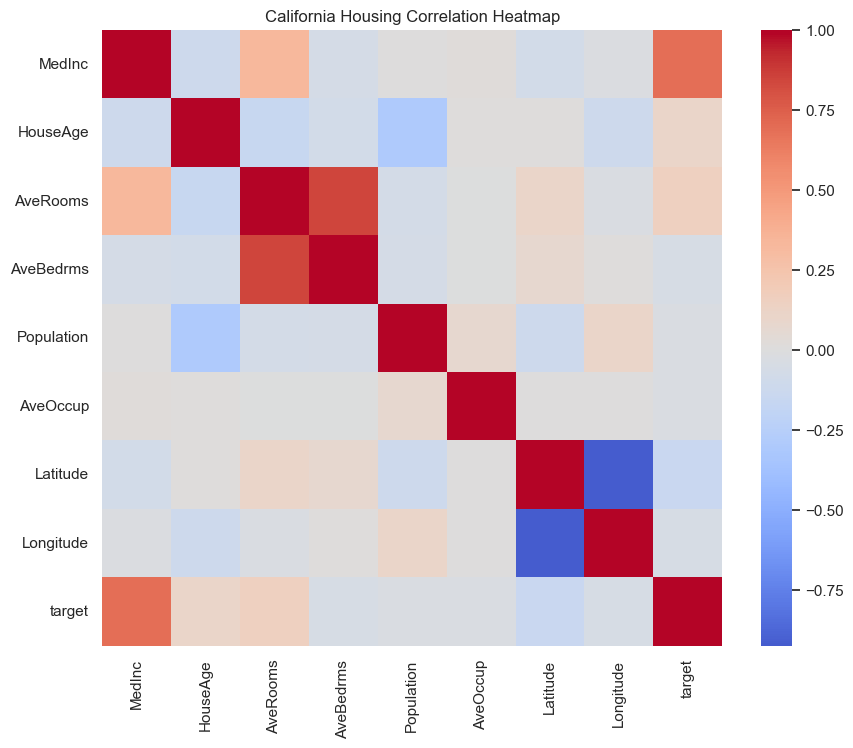

타겟과 상관계수 상위 2개 특성:
MedInc      0.688075
AveRooms    0.151948
Name: target, dtype: float64


In [3]:
# 문제 1: 회귀 데이터 상관관계 분석
reg_df = X_reg.copy()
reg_df['target'] = y_reg

# TODO 1) 상관계수 행렬 계산 메서드
corr = reg_df.corr(numeric_only=True)

# TODO 2) Heatmap 입력 데이터
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('California Housing Correlation Heatmap')
plt.show()

# TODO 3) target과 절대 상관계수 상위 2개 특성 추출
top2 = corr['target'].drop('target').abs().sort_values(ascending=False).head(2)
print('타겟과 상관계수 상위 2개 특성:')
print(top2)

### 문제 1 해석 작성
- (작성) 선택한 2개 특성이 타겟과 연관성이 높은 이유를 데이터셋을 고려하여 추론해보세요.

**답안:**

California Housing 데이터셋에서 타겟(주택 중간 가격)과 가장 높은 절대 상관계수를 보이는 특성은 MedInc(중간 소득)과 AveRooms(평균 방 수)이다. MedInc는 해당 지역의 중간 가구 소득을 나타내며, 소득이 높은 지역일수록 주택 가격이 높은 것은 경제적으로 자연스러운 관계이다. AveRooms는 평균 방 개수로, 방이 많은 주택일수록 면적이 크고 고급 주택일 가능성이 높아 가격과 양의 상관관계를 가진다.

### 문제 2
1. `StandardScaler`로 표준화를 적용하세요.
2. 선형 모델/SVM에서 표준화가 중요한 이유를 서술하세요.


In [4]:
# 문제 2: 회귀 데이터 분할 + 표준화
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
# TODO 4) 학습 데이터에 적용할 메서드
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
# TODO 5) 테스트 데이터에 적용할 메서드
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('표준화 완료:', X_train_reg_scaled.shape, X_test_reg_scaled.shape)

표준화 완료: (16512, 8) (4128, 8)


### 문제 2 해석 작성
- (작성) 선형 모델에서 스케일 차이가 학습 안정성에 미치는 영향
- (작성) SVM/SVR에서 거리 기반 계산과 커널 값에 스케일이 주는 영향

**답안:**

선형 모델에서는 각 특성의 계수(가중치)가 특성 값의 스케일에 직접 영향을 받는다. 스케일이 큰 특성은 경사하강법 과정에서 기울기가 과도하게 커져 학습이 불안정해지고, 수렴이 느려지거나 발산할 수 있다. 표준화를 통해 모든 특성을 동일한 스케일로 맞추면 손실 함수의 등고선이 원형에 가까워져 경사하강법이 더 효율적으로 수렴한다.

SVM/SVR은 데이터 포인트 간의 거리(유클리드 거리)를 기반으로 결정 경계를 찾고, RBF 커널의 경우 K(x,x') = exp(-gamma * ||x-x'||^2)으로 계산된다. 스케일이 큰 특성이 거리 계산을 지배하게 되면, 스케일이 작은 특성의 정보가 사실상 무시된다. 표준화를 적용하면 모든 특성이 거리 계산과 커널 값에 균등하게 기여할 수 있다.

## [Section 2] Linear vs Non-linear

### 문제 3 (회귀)
`LinearRegression` vs `SVR` 성능 비교 및 산점도 작성


In [5]:
# 문제 3: 모델 학습
lr = LinearRegression()
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)

# TODO 6) LinearRegression 학습 메서드
lr.fit(X_train_reg_scaled, y_train_reg)
# TODO 7) SVR 학습 메서드
svr.fit(X_train_reg_scaled, y_train_reg)

# TODO 8) LinearRegression 예측 메서드
pred_lr = lr.predict(X_test_reg_scaled)
# TODO 9) SVR 예측 메서드
pred_svr = svr.predict(X_test_reg_scaled)

result_q3 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)'],
    'MSE': [mean_squared_error(y_test_reg, pred_lr), mean_squared_error(y_test_reg, pred_svr)],
    # TODO 10) R2 계산 시 SVR 예측값 변수
    'R2': [r2_score(y_test_reg, pred_lr), r2_score(y_test_reg, pred_svr)]
})
result_q3

,Model,MSE,R2
0,LinearRegression,0.555892,0.575788
1,SVR(rbf),0.323716,0.752966


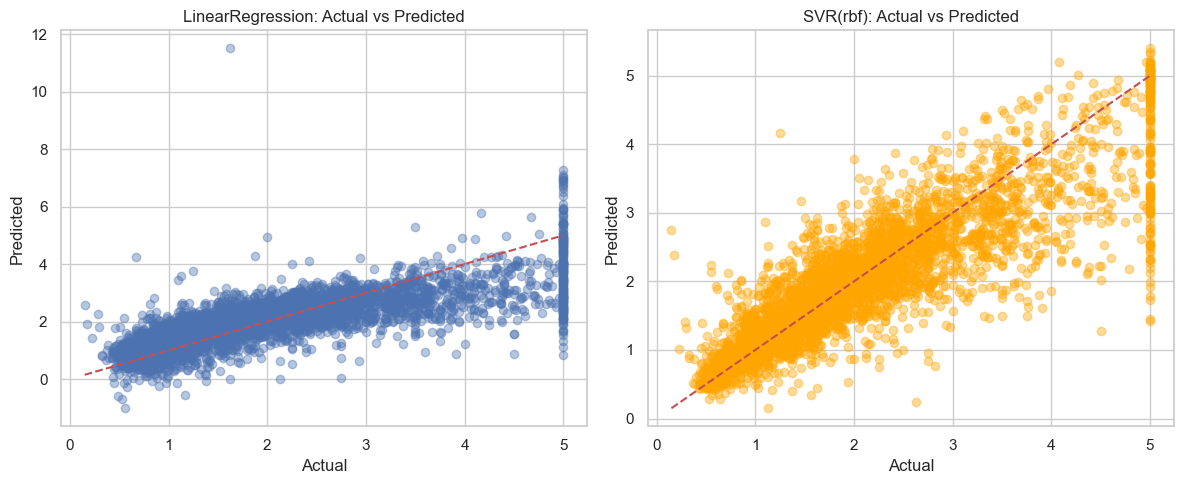

In [6]:
# 문제 3: 산점도 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_reg, pred_lr, alpha=0.4)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[0].set_title('LinearRegression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test_reg, pred_svr, alpha=0.4, color='orange')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[1].set_title('SVR(rbf): Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


### 문제 3 해석 작성
- (작성) 선형 모델의 한계가 드러난 패턴
- (작성) SVR 성능 개선 이유(비선형 함수 언급)

**답안:**

산점도에서 LinearRegression은 실제값과 예측값 사이에 체계적인 편차가 관찰된다. 특히 고가 주택(실제값이 큰 영역)에서 예측값이 실제값에 미치지 못하는 패턴이 나타나는데, 이는 선형 모델이 데이터 내 비선형 관계를 포착하지 못하는 한계를 보여준다. 주택 가격은 소득, 위치 등 여러 특성과 복잡한 비선형 관계를 가지기 때문이다.

SVR(rbf)은 RBF(Radial Basis Function) 커널을 통해 입력 데이터를 고차원 특성 공간으로 매핑하여 비선형 관계를 학습할 수 있다. 이를 통해 선형 모델이 놓치는 복잡한 패턴을 포착하여 MSE가 낮아지고 R2가 높아지는 성능 개선이 이루어진다.

### 문제 4
SVR의 `C`, `epsilon`을 바꿔 성능 변화를 관찰하고, 과적합 방지 전략을 설명하세요.


In [7]:
# 문제 4: 하이퍼파라미터 실험
C_list = [1, 10, 50]
eps_list = [0.01, 0.1, 0.3]

rows = []
for c in C_list:
    for eps in eps_list:
        # TODO 11) 루프 변수 c, eps를 SVR에 적용
        model = SVR(kernel='rbf', C=c, epsilon=eps)
        model.fit(X_train_reg_scaled, y_train_reg)
        pred = model.predict(X_test_reg_scaled)
        rows.append({
            'C': c,
            'epsilon': eps,
            'MSE': mean_squared_error(y_test_reg, pred),
            'R2': r2_score(y_test_reg, pred)
        })

# TODO 12) R2 기준 내림차순
svr_grid_result = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
svr_grid_result

,C,epsilon,MSE,R2
0,50,0.30,0.309481,0.763829
1,50,0.10,0.316283,0.758638
2,50,0.01,0.318310,0.757091
3,10,0.30,0.319305,0.756332
4,10,0.10,0.323716,0.752966
5,10,0.01,0.324229,0.752574
6,1,0.30,0.352804,0.730768
7,1,0.10,0.357004,0.727563
8,1,0.01,0.357789,0.726964


### 문제 4 해석 작성
- (작성) `C` 증가/감소가 편향 및 분산에 미치는 영향
- (작성) `epsilon` 변화가 예측 민감도에 미치는 영향
- (작성) 결론 작성(과적합 방지 전략)

**답안:**

C는 규제(regularization)의 강도를 조절하는 파라미터이다. C가 증가하면 오차에 대한 패널티가 커져 모델이 학습 데이터에 더 정밀하게 맞추려 하므로 편향(Bias)은 감소하지만 분산(Variance)이 증가하여 과적합 위험이 커진다. 반대로 C가 감소하면 오차를 더 허용하여 편향은 증가하지만 분산이 감소하여 일반화 성능이 좋아질 수 있다.

epsilon은 예측값 주변의 허용 오차 범위(epsilon-tube)를 정의한다. epsilon이 작으면 허용 범위가 좁아져 더 많은 데이터 포인트가 서포트 벡터로 사용되어 모델이 민감해진다. epsilon이 크면 허용 범위가 넓어져 작은 오차를 무시하므로 모델이 덜 민감하고 단순해진다.

결론적으로, 과적합을 방지하려면 C를 적절히 줄여 규제를 강화하고, epsilon을 적절히 키워 노이즈에 둔감하게 만드는 것이 좋다. 교차 검증(Cross-Validation)을 통해 최적의 C와 epsilon 조합을 찾는 것이 일반화 성능을 극대화하는 핵심 전략이다.

## [Section 3] Decision Tree & Ensemble

### 문제 5
`DecisionTreeRegressor` vs `RandomForestRegressor` 성능 비교


In [8]:
# 문제 5: Bagging 비교
dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

# TODO 13) DecisionTree 학습 메서드
dt.fit(X_train_reg, y_train_reg)
# TODO 14) RandomForest 학습 메서드
rf.fit(X_train_reg, y_train_reg)
pred_dt = dt.predict(X_test_reg)
pred_rf = rf.predict(X_test_reg)

result_q5 = pd.DataFrame({
    'Model': ['DecisionTreeRegressor', 'RandomForestRegressor'],
    'MSE': [mean_squared_error(y_test_reg, pred_dt), mean_squared_error(y_test_reg, pred_rf)],
    'R2': [r2_score(y_test_reg, pred_dt), r2_score(y_test_reg, pred_rf)]
})
result_q5

,Model,MSE,R2
0,DecisionTreeRegressor,0.422045,0.677928
1,RandomForestRegressor,0.272705,0.791893


### 문제 5 해석 작성
- (작성) 왜 Random Forest가 단일 트리보다 Variance를 줄이는가?
- (작성) Diversity Theorem 관점에서 샘플 및 특성 랜덤성의 역할

**답안:**

Random Forest는 여러 개의 Decision Tree를 학습시킨 뒤 그 예측값을 평균(회귀) 또는 다수결(분류)로 결합하는 Bagging 앙상블 기법이다. 단일 트리는 학습 데이터의 작은 변화에도 구조가 크게 달라지는 높은 분산을 가지지만, 여러 트리의 예측을 평균하면 개별 트리의 랜덤한 오차가 상쇄되어 분산이 줄어든다(Var(평균) = Var(개별)/n, 독립 가정 시).

Diversity Theorem 관점에서, 앙상블의 성능은 개별 모델의 정확도뿐만 아니라 모델 간의 다양성(diversity)에 의해 결정된다. Random Forest는 두 가지 랜덤성을 도입하여 다양성을 확보한다: (1) Bootstrap Sampling으로 각 트리마다 서로 다른 학습 데이터 부분집합을 사용하고, (2) 각 분할(split) 시 전체 특성이 아닌 랜덤하게 선택된 특성 부분집합만 고려한다. 이 두 가지 랜덤성이 트리 간 상관관계를 낮추어 앙상블의 분산 감소 효과를 극대화한다.

### 문제 6
Boosting 성능 비교 및 Residual 학습 원리


In [9]:
# 문제 6: Boosting
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=3)

# TODO 15) GradientBoosting 학습 메서드
gbr.fit(X_train_reg, y_train_reg)
# TODO 16) GradientBoosting 예측 메서드
pred_gbr = gbr.predict(X_test_reg)

result_q6 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)', 'DecisionTreeRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MSE': [
        mean_squared_error(y_test_reg, pred_lr),
        mean_squared_error(y_test_reg, pred_svr),
        mean_squared_error(y_test_reg, pred_dt),
        mean_squared_error(y_test_reg, pred_rf),
        mean_squared_error(y_test_reg, pred_gbr)
    ],
    'R2': [
        r2_score(y_test_reg, pred_lr),
        r2_score(y_test_reg, pred_svr),
        r2_score(y_test_reg, pred_dt),
        r2_score(y_test_reg, pred_rf),
        r2_score(y_test_reg, pred_gbr)
    ]
}).sort_values('R2', ascending=False).reset_index(drop=True)
result_q6

,Model,MSE,R2
0,RandomForestRegressor,0.272705,0.791893
1,GradientBoostingRegressor,0.291214,0.777768
2,SVR(rbf),0.323716,0.752966
3,DecisionTreeRegressor,0.422045,0.677928
4,LinearRegression,0.555892,0.575788


### 문제 6 해석 작성
- (작성) GBM이 이전 단계 잔차를 어떤 방식으로 학습하는지 단계별로 설명
- (작성) 위 실험에서의 GBM과 랜덤포레스트의 성능(R2) 차이를 Bias-Variance Trade-off로 해석

**답안:**

GBM(Gradient Boosting Machine)의 잔차 학습 과정:
1. 초기 모델 F0(x)으로 전체 데이터의 평균값을 예측한다.
2. 1단계: 실제값과 F0(x)의 잔차(residual) r1 = y - F0(x)를 계산하고, 이 잔차를 타겟으로 하는 약한 학습기(얕은 트리) h1(x)을 학습한다.
3. 모델을 F1(x) = F0(x) + lr * h1(x)로 업데이트한다 (lr = learning_rate).
4. 2단계: 새로운 잔차 r2 = y - F1(x)를 계산하고, 다시 h2(x)를 학습한다.
5. 이 과정을 n_estimators(200회)만큼 반복하여 최종 모델 F(x) = F0(x) + lr * sum(hi(x))를 구성한다.

Bias-Variance Trade-off 관점에서, Random Forest는 Bagging 기법으로 분산을 줄이는 데 초점을 맞추지만 편향 감소에는 한계가 있다. 반면 GBM은 Boosting 기법으로 이전 모델의 잔차(오류)를 순차적으로 보정하므로 편향을 효과적으로 줄인다. 낮은 learning_rate(0.05)와 얕은 트리(max_depth=3)를 사용하여 과적합(분산 증가)을 억제하면서도, 많은 반복(200회)을 통해 편향을 충분히 낮출 수 있다. 따라서 GBM이 RF보다 높은 R2를 달성할 수 있다.

## [Section 4] 결론 및 분석

### 문제 7
분류 문제에서 Accuracy가 아닌 F1-score가 중요한 상황을 확인하세요.


In [10]:
# 문제 7: 분류
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE,
    # TODO 17) 클래스 비율 유지를 위한 설정
    stratify=y_clf
)

scaler_clf = StandardScaler()
# TODO 18) 분류 데이터 학습 스케일링 메서드
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

from sklearn.ensemble import RandomForestClassifier
clf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
clf_model.fit(X_train_clf, y_train_clf)
pred_clf = clf_model.predict(X_test_clf)

print('Accuracy:', accuracy_score(y_test_clf, pred_clf))
print('F1-macro:', f1_score(y_test_clf, pred_clf, average='macro'))
print('F1-weighted:', f1_score(y_test_clf, pred_clf, average='weighted'))
print('\nClassification Report\n', classification_report(y_test_clf, pred_clf))

Accuracy: 1.0
F1-macro: 1.0
F1-weighted: 1.0

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### 문제 7 해석 작성
- (작성) Accuracy가 왜 클래스 불균형 데이터에서 왜곡될 수 있는지
- (작성) F1-score를 Accuracy보다 우선 확인해야 하는 상황 예시 (앞 문항과 연결하여 작성)

**답안:**

클래스 불균형 데이터에서 Accuracy는 다수 클래스를 올바르게 예측하는 것만으로도 높은 값을 가질 수 있어 왜곡된다. 예를 들어, 양성(암) 환자가 5%이고 음성이 95%인 데이터에서, 모든 샘플을 음성으로 예측해도 Accuracy는 95%가 된다. 이 경우 소수 클래스(암 환자)를 전혀 찾지 못하면서도 높은 정확도를 보이는 문제가 발생한다.

F1-score는 Precision과 Recall의 조화평균으로, 소수 클래스에 대한 예측 성능을 정확히 반영한다. 앞서 지도학습 PDF에서 다룬 유방암 진단(Wisconsin Breast Cancer) 문제처럼, 암 환자를 놓치는 것(False Negative)의 비용이 매우 크고 클래스 비율이 불균형한 의료 진단 상황에서는 Accuracy보다 F1-score(특히 Recall)를 우선적으로 확인해야 한다. macro-F1은 각 클래스의 F1을 동일 가중치로 평균하여 소수 클래스의 성능도 공정하게 반영한다.

### 문제 8
최종 선택 모델의 Feature Importance를 출력하고 도메인 관점으로 왜 이러한 결과가 나왔는지 생각해보세요 ^ㅡ^


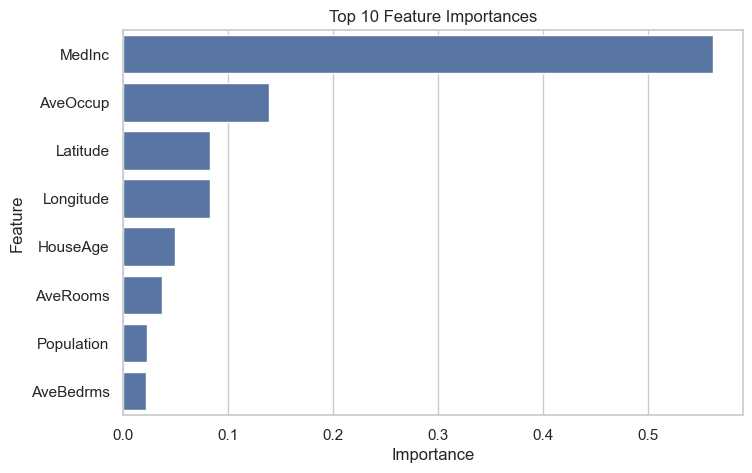

MedInc        0.561584
AveOccup      0.138822
Latitude      0.083421
Longitude     0.083235
HouseAge      0.050168
AveRooms      0.037382
Population    0.022891
AveBedrms     0.022497
dtype: float64

In [11]:
# 문제 8: 특성 중요도 시각화
final_model = rf
importance = pd.Series(final_model.feature_importances_, index=X_train_reg.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values[:10], y=importance.index[:10], orient='h')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

importance.head(10)


## 제출 전 체크리스트
- [ ] Section 1~4 모든 코드 작성 및 실행
- [ ] 서술형 문항 답안 작성


긴 과제 진행하시느라 정말 고생 많으셨습니다.

코드작성과 해석을 스스로 정리해보신 만큼, 지도학습 핵심 개념을 탄탄하게 가져가는 기회가 되셨으면 합니다.
감사합니다.
